#### `Imports`

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import json

In [2]:
RUL_MAX = 125
feature_cols = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
    'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_17',
    'sensor_20', 'sensor_21'
]

### `load tensors`

In [3]:
# load tensors
X_tr = torch.load('../Dataset/FD001/X_train.pt')
y_tr = torch.load('../Dataset/FD001/y_train.pt')
X_val = torch.load('../Dataset/FD001/X_val.pt')
y_val = torch.load('../Dataset/FD001/y_val.pt')
X_test = torch.load('../Dataset/FD001/X_test.pt')
y_test = torch.load('../Dataset/FD001/y_test.pt')

## **LSTM Modeling**

### `Create datasets and dataloaders`

In [4]:
BATCH_SIZE = 64

In [5]:
train_dataset = TensorDataset(X_tr, y_tr)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

len(train_loader), len(val_loader), len(test_loader)

(236, 42, 2)

### `Define the model`

In [6]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=13, hidden_size=64, num_layers=2, dropout=0.35):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        return self.regressor(last_out).squeeze(1)

### `Device, model, loss, optimizer`


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [8]:
model = LSTMRegressor(input_size=13, hidden_size=64, num_layers=2, dropout=0.35).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

### `Training and validation loops`

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            preds_list.append(preds.cpu())
            targets_list.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    preds_all = torch.cat(preds_list)
    targets_all = torch.cat(targets_list)

    return avg_loss, preds_all, targets_all

### `Train the model`

In [10]:
NUM_EPOCHS = 50
PATIENCE = 7

In [11]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience_counter = 0

best_model_path = '../Dataset/FD001/best_lstm_fd001_regularized.pt'

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Patience: {patience_counter}/{PATIENCE}"
    )

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

Epoch [1/50] | Train Loss: 6154.4500 | Val Loss: 3378.7805 | Patience: 0/7
Epoch [2/50] | Train Loss: 1822.8176 | Val Loss: 644.9420 | Patience: 0/7
Epoch [3/50] | Train Loss: 656.5536 | Val Loss: 255.5981 | Patience: 0/7
Epoch [4/50] | Train Loss: 545.7974 | Val Loss: 200.2761 | Patience: 0/7
Epoch [5/50] | Train Loss: 499.4954 | Val Loss: 188.8515 | Patience: 0/7
Epoch [6/50] | Train Loss: 475.6204 | Val Loss: 195.6071 | Patience: 1/7
Epoch [7/50] | Train Loss: 479.9928 | Val Loss: 160.3697 | Patience: 0/7
Epoch [8/50] | Train Loss: 458.9936 | Val Loss: 174.0380 | Patience: 1/7
Epoch [9/50] | Train Loss: 437.5417 | Val Loss: 177.7512 | Patience: 2/7
Epoch [10/50] | Train Loss: 403.9683 | Val Loss: 174.1010 | Patience: 3/7
Epoch [11/50] | Train Loss: 394.6648 | Val Loss: 187.1579 | Patience: 4/7
Epoch [12/50] | Train Loss: 361.4602 | Val Loss: 181.3426 | Patience: 5/7
Epoch [13/50] | Train Loss: 366.0709 | Val Loss: 174.4797 | Patience: 6/7
Epoch [14/50] | Train Loss: 367.0996 | Val L

In [12]:
''' train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_path = '../Dataset/FD001/best_lstm_fd001.pt'

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
'''

' train_losses = []\nval_losses = []\n\nbest_val_loss = float(\'inf\')\nbest_model_path = \'../Dataset/FD001/best_lstm_fd001.pt\'\n\nfor epoch in range(NUM_EPOCHS):\n    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)\n    val_loss, _, _ = evaluate(model, val_loader, criterion, device)\n\n    train_losses.append(train_loss)\n    val_losses.append(val_loss)\n\n    if val_loss < best_val_loss:\n        best_val_loss = val_loss\n        torch.save(model.state_dict(), best_model_path)\n\n    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")\n'

### `Plot training curves`

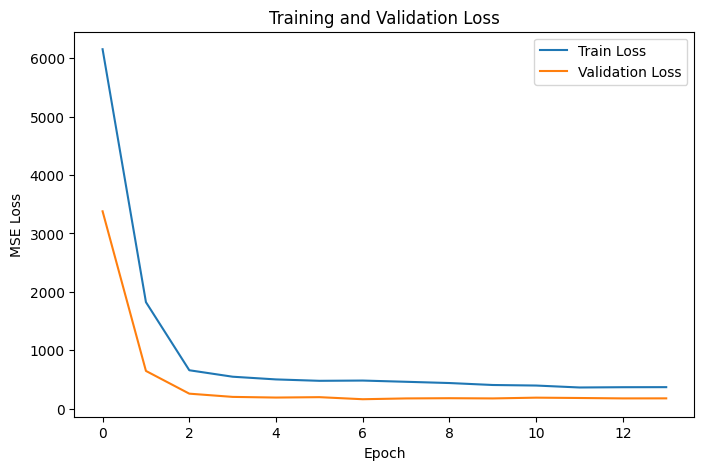

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

### `Load best model and evaluate on test`

In [14]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, y_pred_test, y_true_test = evaluate(model, test_loader, criterion, device)

print("Test MSE:", test_loss)

Test MSE: 189.57326110839844


### `RMSE and MAE`

In [15]:
y_true_np = y_true_test.numpy()
y_pred_np = y_pred_test.numpy()

rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
mae = mean_absolute_error(y_true_np, y_pred_np)

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 13.768560471098242
Test MAE: 9.847209930419922


### `Predicted vs actual plot`


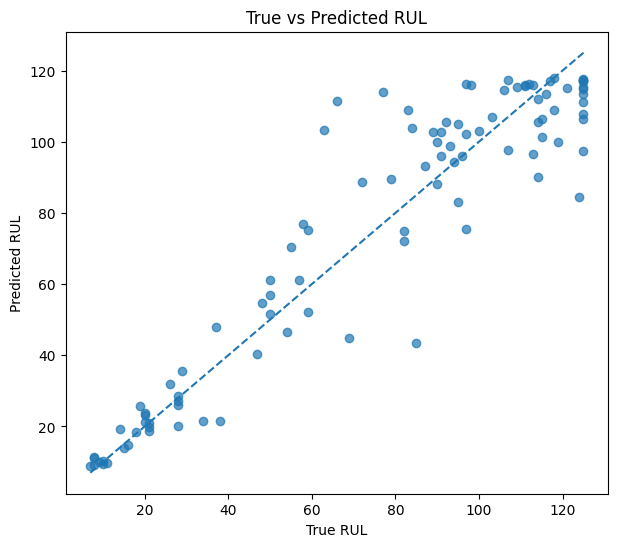

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_true_np, y_pred_np, alpha=0.7)

min_val = min(y_true_np.min(), y_pred_np.min())
max_val = max(y_true_np.max(), y_pred_np.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("True vs Predicted RUL")
plt.show()

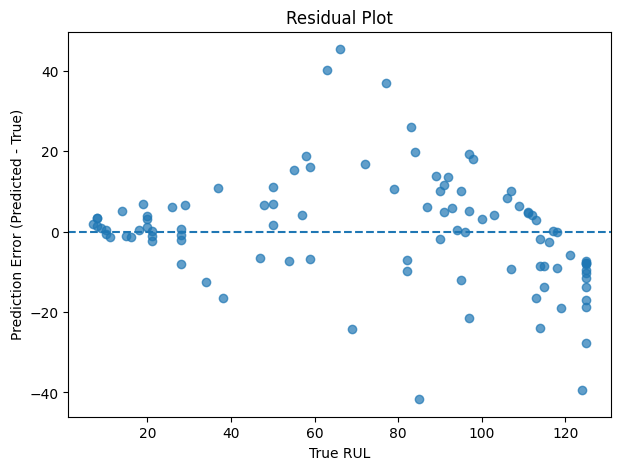

In [17]:
residuals = y_pred_np - y_true_np

plt.figure(figsize=(7, 5))
plt.scatter(y_true_np, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')

plt.xlabel("True RUL")
plt.ylabel("Prediction Error (Predicted - True)")
plt.title("Residual Plot")
plt.show()


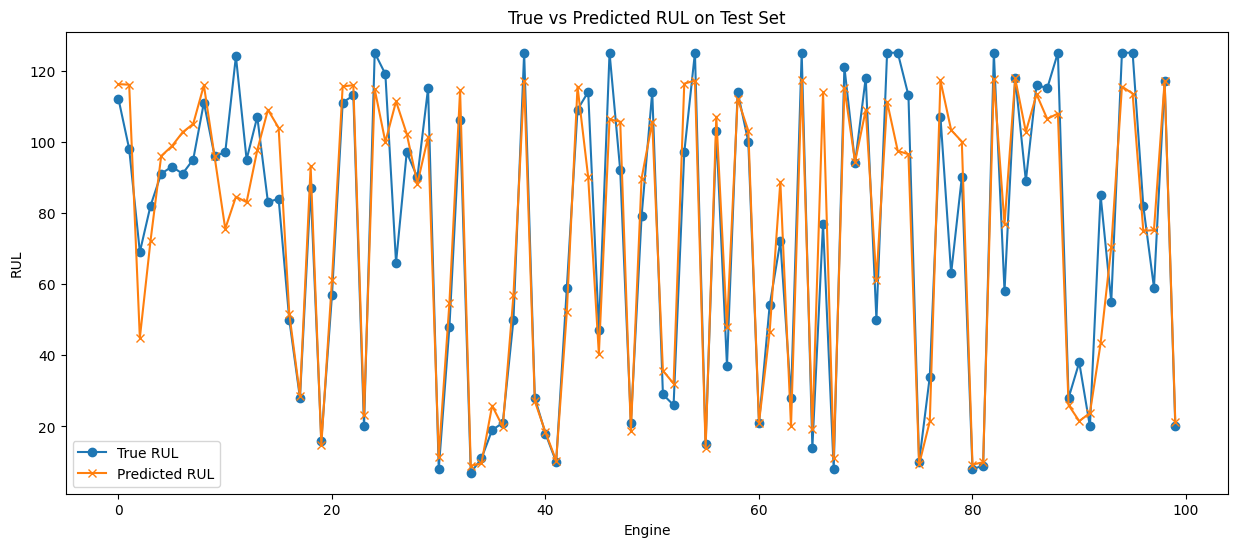

In [18]:
plt.figure(figsize=(15, 6))
plt.plot(y_true_np, label='True RUL', marker='o')
plt.plot(y_pred_np, label='Predicted RUL', marker='x')
plt.title('True vs Predicted RUL on Test Set')
plt.xlabel('Engine')
plt.ylabel('RUL')
plt.legend()
plt.show()

In [19]:
# number of engines the model got right and wrong (within 15 cycles error)
correct = np.sum(np.abs(y_pred_np - y_true_np) <= 15)
print(f"Engines with prediction error <= 15 cycles: {correct}/{len(y_true_np)}")

Engines with prediction error <= 15 cycles: 78/100


### `Save model + config`

In [20]:
SAVE_DIR = "../Dataset/FD001"

torch.save(model.state_dict(), f"{SAVE_DIR}/best_lstm_fd001.pt")

config = {
    "window_size": 30,
    "input_size": 13,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.35,
    "rul_max": RUL_MAX,
    "feature_cols": feature_cols
}

with open(f"{SAVE_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=4)

## **Failure Probability**

In [21]:
def compute_failure_probability(predicted_rul, rul_max=125):
    p_failure = 1 - (predicted_rul / rul_max)
    return float(np.clip(p_failure, 0, 1))